## Read the images and generate the train and test dataset (10 points)

In [2]:
# Importing all the required python modules 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import math 
import cv2 
from glob import glob 
import itertools

# Importing Keras modules
from keras.utils import np_utils
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling2D
from keras.layers import BatchNormalization
from keras.callbacks import ModelCheckpoint,ReduceLROnPlateau,CSVLogger

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Set the random seed 
seed = 7

# Set the image width/height scale 
scale = 64

Using TensorFlow backend.


In [3]:
# mount the google-drive 
from google.colab import drive
drive.mount('/gdrive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /gdrive


In [4]:
# Copy the files into the local VM for faster processing 

%%bash
cp "/gdrive/My Drive/GreatLearning/Lab/CNN_Proj/plant-seedlings-classification.zip" /content/
7z x /content/plant-seedlings-classification.zip
7z x /content/train.zip
7z x /content/test.zip

rm /content/plant-seedlings-classification.zip
rm /content/train.zip
rm /content/test.zip


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
1 file, 1808816010 bytes (1726 MiB)

Extracting archive: /content/plant-seedlings-classification.zip
--
Path = /content/plant-seedlings-classification.zip
Type = zip
Physical Size = 1808816010

Everything is Ok

Files: 3
Size:       1808691392
Compressed: 1808816010

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
1 file, 1718530069 bytes (1639 MiB)

Extracting archive: /content/train.zip
--
Path = /content/train.zip
Type = zip
Physical Size = 1718530069

Everything is Ok

Folders: 13
Files: 4750
Size:       1722261514
Compressed: 1718530069

7-Zip [64] 16.02 : Copyright (c) 1999-

In [5]:
# Check the #Imagefiles in Train and Test folders
%%bash
find /content/train -name  "*.png" | wc -l
find /content/test -name  "*.png" | wc -l

4750
794


#### Load all the train plant-seeding images from the train-folder

In [0]:
FILE_PATH = '/content/train/*/*.png'
images = glob(FILE_PATH)
trainingset = []
traininglabels = []
num = len(images)
count = 1

#Read the images and resize them to 128*128
for i in images:
    #print(i)
    #print(str(count)+'/'+str(num),end='\n\r')
    trainingset.append(cv2.resize(cv2.imread(i),(scale,scale)))
    traininglabels.append(i.split('/')[-2])
    count=count+1
    #if count >500: 
    #  break

In [7]:
print ("Training-Set Images#=", len(trainingset))

# TrainingSet as np-array and TrainingLabels as classes  
trainingset = np.asarray(trainingset)
traininglabels = pd.DataFrame(traininglabels)

Training-Set Images#= 4750


#### Converting the plant labels into numbers

12


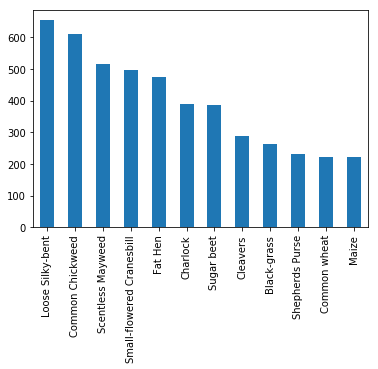

In [8]:
labels = preprocessing.LabelEncoder()
labels.fit(traininglabels[0])

encodedlabels = labels.transform(traininglabels[0])
clearalllabels = np_utils.to_categorical(encodedlabels)
classes = clearalllabels.shape[1]
print(str(classes))
traininglabels[0].value_counts().plot(kind='bar')

## Divide the data set into Train and validation data sets

In [0]:
#Do Train/Validation Split 

# Use the images as it is from the TrainSet without any cleaning/removing background 
trainingset_norm = trainingset/255
x_train,x_val,y_train,y_val = train_test_split(trainingset_norm,clearalllabels,test_size=0.2,random_state=seed,stratify=clearalllabels)

In [10]:
print (x_train.shape, y_train.shape, x_val.shape, y_val.shape)

(3800, 64, 64, 3) (3800, 12) (950, 64, 64, 3) (950, 12)


#### Prevent overfitting by using image-generator with different variations 

In [0]:
generator = ImageDataGenerator(rotation_range = 180,zoom_range = 0.1,width_shift_range = 0.1,height_shift_range = 0.1,horizontal_flip = True,vertical_flip = True)
generator.fit(x_train)

## Initialize & build the model (20 points)

In [12]:
#Updating the model with adam optimized and additional CNN layers 
  
np.random.seed(seed)

model = Sequential()

model.add(Conv2D(filters=64, kernel_size=(5, 5), input_shape=(scale, scale, 3), activation='relu'))
model.add(BatchNormalization(axis=3))
model.add(Conv2D(filters=64, kernel_size=(5, 5), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(BatchNormalization(axis=3))
model.add(Dropout(0.1))

model.add(Conv2D(filters=128, kernel_size=(5, 5), activation='relu'))
model.add(BatchNormalization(axis=3))
model.add(Conv2D(filters=128, kernel_size=(5, 5), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(BatchNormalization(axis=3))
model.add(Dropout(0.1))

model.add(Conv2D(filters=256, kernel_size=(5, 5), activation='relu'))
model.add(BatchNormalization(axis=3))
model.add(Conv2D(filters=256, kernel_size=(5, 5), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(BatchNormalization(axis=3))
model.add(Dropout(0.1))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Number of class-labels for output 
model.add(Dense(classes, activation='softmax'))

# categorical output of 12 labels 
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

initial_weights = model.get_weights()

model.summary()








Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 60, 60, 64)        4864      
_________________________________________________________________
batch_normalization_1 (Batch (None, 60, 60, 64)        256       
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 56, 56, 64)        102464    
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 28, 28, 64)        0         
_________________________________________________________________
batch_normalization_2 (Batch (None, 28, 28, 64)        256       
_________________________________________________________________
dropout_1 (Dropout)          (None, 28, 28, 64)        0       

In [13]:
#Fitting the CNN onto the data:

# Using the learning-rate callback with patience as 3 
lrr = ReduceLROnPlateau(monitor='val_acc', 
                        patience=3, 
                        verbose=1, 
                        factor=0.4, 
                        min_lr=0.00001)


callbacks_list = [lrr]

# setting the batch-size to 128 
bt_size = 128

# Model generator so that images get loaded batch-wise incrementally and memory is not an issue 
hist1 = model.fit_generator(generator.flow(x_train, y_train, batch_size=bt_size), 
                            epochs=10, validation_data=(x_val, y_val), 
                            steps_per_epoch=x_train.shape[0]/bt_size, callbacks=callbacks_list)

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Epoch 1/10
30/29 [==============================] - 455s 15s/step - loss: 2.7591 - acc: 0.2452 - val_loss: 10.4278 - val_acc: 0.0958
Epoch 2/10
30/29 [==============================] - 456s 15s/step - loss: 1.8870 - acc: 0.4166 - val_loss: 3.5201 - val_acc: 0.2968
Epoch 3/10
30/29 [==============================] - 465s 16s/step - loss: 1.4547 - acc: 0.5299 - val_loss: 3.3859 - val_acc: 0.3979
Epoch 4/10
30/29 [==============================] - 472s 16s/step - loss: 1.2332 - acc: 0.6006 - val_loss: 3.5080 - val_acc: 0.4653
Epoch 5/10
30/29 [==============================] - 471s 16s/step - loss: 1.0806 - acc: 0.6394 - val_loss: 1.9206 - val_acc: 0.5726
Epoch 6/10
30/29 [==============================] - 471s 16s/step - loss: 0.9443 - acc: 0.6861 - val_loss: 3.1505 - val_acc: 0.4158
Epoch 7/10
30/29 [==============================] - 467s 16s/step - loss: 0.8452 - acc: 0.7202 - val_loss: 2.8836

## Predict the accuracy for both train and validation data using initial model 

In [0]:
# plot diagnostic learning curves
def cross_entropy_plot(history):
	# plot loss
	plt.subplot(211)
	plt.title('Cross Entropy Loss')
	plt.plot(history.history['loss'], color='blue', label='train')
	plt.plot(history.history['val_loss'], color='orange', label='test')

def classification_acc_plot(history):
	# plot accuracy
	plt.subplot(212)
	plt.title('Classification Accuracy')
	plt.plot(history.history['acc'], color='blue', label='train')
	plt.plot(history.history['val_acc'], color='orange', label='test')

#### Evaluate model on Train and Validation Data 

In [16]:
# Evaluate on train-set
_, train_acc = model.evaluate(x_train, y_train)
print("Train-Accuracy =", train_acc)  

# Evaluate on validation-set
_, val_acc = model.evaluate(x_val, y_val)
print("Validation-Accuracy =", val_acc )  

3800/3800 [==============================] - 102s 27ms/step
Train-Accuracy = 0.5131578947368421
950/950 [==============================] - 26s 27ms/step
Validation-Accuracy = 0.5052631578947369


In [17]:
#Confusion Matrix:

y_pred = model.predict(x_val)
y_class = np.argmax(y_pred, axis = 1) 
y_check = np.argmax(y_val, axis = 1) 

cmatrix = confusion_matrix(y_check, y_class)
print(cmatrix)

[[ 29   0   0   1   0   1  13   0   0   0   3   6]
 [  0  53   1   0   0   0   0  11   0  10   3   0]
 [  0   3  13   0   3   0   0   7   0   8  19   5]
 [  0   0   1 113   0   0   0   6   0   2   0   0]
 [ 12   0   8   0  12   0   1   1   1   0   1   8]
 [  1   0   0  27   0   8   4   2   2   0  48   3]
 [ 41   0   0   3   0   2  82   0   1   0   1   1]
 [  0   1   0  10   0   1   0  30   0   0   1   1]
 [  0   0   0  38   0   1   4  12   9   9   3  27]
 [  0   0   0  15   0   0   0   5   0  20   1   5]
 [  0   0   1  20   0   0   0   1   0   7  70   0]
 [  0   0   0   8   0   0   0   6   0   0  22  41]]


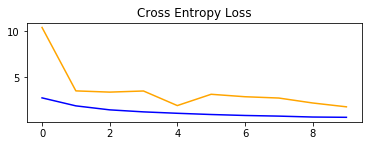

In [18]:
# cross-entropy plot
cross_entropy_plot(hist1)

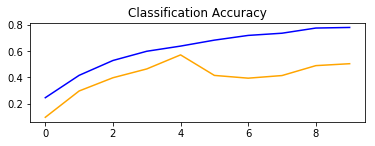

In [19]:
# accuracy plot 
classification_acc_plot(hist1)

## Optimize the model for better accuracy (16 points)

#### Cleanup Image by taking mask of seed-part and removing background

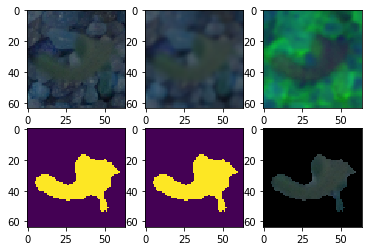

In [20]:
# Clean the images and remove the background. Copy the images into new_train_set

new_train = []
sets = []; getEx = True
for i in trainingset:
    blurr = cv2.GaussianBlur(i,(5,5),0)
    hsv = cv2.cvtColor(blurr,cv2.COLOR_BGR2HSV)
    
    # Identify the green-pixel areas  
    lower = (25,40,50)
    upper = (75,255,255)
    mask = cv2.inRange(hsv,lower,upper)
    
    # Get the image with green-pixel area using mask 
    struc = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(11,11))
    mask = cv2.morphologyEx(mask,cv2.MORPH_CLOSE,struc)
    boolean = mask>0
    new = np.zeros_like(i,np.uint8)
    new[boolean] = i[boolean]
    new_train.append(new)
    
    if getEx:
        plt.subplot(2,3,1);plt.imshow(i) # ORIGINAL
        plt.subplot(2,3,2);plt.imshow(blurr) # BLURRED
        plt.subplot(2,3,3);plt.imshow(hsv) # HSV CONVERTED
        plt.subplot(2,3,4);plt.imshow(mask) # MASKED
        plt.subplot(2,3,5);plt.imshow(boolean) # BOOLEAN MASKED
        plt.subplot(2,3,6);plt.imshow(new) # NEW PROCESSED IMAGE
        plt.show()
        getEx = False

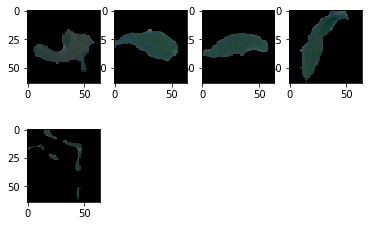

In [21]:
# Set the new-train-dataset with the cleaned-up images 
new_train = np.asarray(new_train)

# Diaplay random cleaned images 
for i in range(5):
    plt.subplot(2,4,i+1)
    plt.imshow(new_train[i])

#### Use the new-train-set from preprocessed images and do Train/Val Split

In [0]:
# Use the cleaned images  for this model 
new_train = new_train/255
x_train,x_val,y_train,y_val = train_test_split(new_train,clearalllabels,test_size=0.2,random_state=seed,stratify=clearalllabels)

In [23]:
print (x_train.shape, y_train.shape, x_val.shape, y_val.shape)

(3800, 64, 64, 3) (3800, 12) (950, 64, 64, 3) (950, 12)


#### Run the model on the new preprocessed image data-set

In [0]:
#Prevent overfitting by using image-generator with different variations 
generator = ImageDataGenerator(rotation_range = 180,zoom_range = 0.1,width_shift_range = 0.1,height_shift_range = 0.1,horizontal_flip = True,vertical_flip = True)
generator.fit(x_train)

In [0]:
# ReInitialize the weights, so that model can be run on a different data-set
model.set_weights(initial_weights)

In [27]:
#Fitting the CNN onto the data:

# Using the learning-rate callback with patience as 2 
lrr = ReduceLROnPlateau(monitor='val_acc', 
                        patience=2, 
                        verbose=1, 
                        factor=0.4, 
                        min_lr=0.00001)

# Saving the model-best-accuracy weights in a file 
filepath="/gdrive/My Drive/GreatLearning/Lab/CNN_Proj/weights_{epoch:02d}-{val_acc:.2f}.hdf5"
checkpoints = ModelCheckpoint(filepath, monitor='val_acc', 
                              verbose=1, save_best_only=True, mode='max')

callbacks_list = [checkpoints, lrr]
bt_size = 128

# Model generator so that images get loaded batch-wise incrementally and memory is not an issue 
hist2 = model.fit_generator(generator.flow(x_train, y_train, batch_size=bt_size), 
                            epochs=10, validation_data=(x_val, y_val), 
                            steps_per_epoch=x_train.shape[0]/bt_size, callbacks=callbacks_list)

Epoch 1/10
30/29 [==============================] - 463s 15s/step - loss: 0.9964 - acc: 0.6685 - val_loss: 0.8074 - val_acc: 0.7116

Epoch 00001: val_acc improved from -inf to 0.71158, saving model to /gdrive/My Drive/GreatLearning/Lab/CNN_Proj/weights_01-0.71.hdf5
Epoch 2/10
30/29 [==============================] - 465s 15s/step - loss: 0.9515 - acc: 0.6779 - val_loss: 0.7504 - val_acc: 0.7453

Epoch 00002: val_acc improved from 0.71158 to 0.74526, saving model to /gdrive/My Drive/GreatLearning/Lab/CNN_Proj/weights_02-0.75.hdf5
Epoch 3/10
30/29 [==============================] - 463s 15s/step - loss: 0.9287 - acc: 0.6856 - val_loss: 1.0281 - val_acc: 0.6789

Epoch 00003: val_acc did not improve from 0.74526
Epoch 4/10
30/29 [==============================] - 464s 15s/step - loss: 0.8514 - acc: 0.7162 - val_loss: 1.5705 - val_acc: 0.5937

Epoch 00004: val_acc did not improve from 0.74526

Epoch 00004: ReduceLROnPlateau reducing learning rate to 0.00016000000759959222.
Epoch 5/10
30/29 

## Predict on the optimized model (14 points) 

#### Evaluate the model on the Train/Validation data-set

In [28]:
# Evaluate on train-set
_, train_acc = model.evaluate(x_train, y_train)
print("Updated-Model - Train-Accuracy =", train_acc)  

# Evaluate on validation-set
_, val_acc = model.evaluate(x_val, y_val)
print("Updated-Model - Validation-Accuracy =", val_acc )   

3800/3800 [==============================] - 104s 27ms/step
Updated-Model - Train-Accuracy = 0.8199999998745165
950/950 [==============================] - 26s 27ms/step
Updated-Model - Validation-Accuracy = 0.8157894741861443


In [29]:
#Confusion Matrix:

y_pred = model.predict(x_val)
y_class = np.argmax(y_pred, axis = 1) 
y_check = np.argmax(y_val, axis = 1) 

cmatrix = confusion_matrix(y_check, y_class)
print(cmatrix)

[[  3   0   0   0   2   0  42   0   5   0   0   1]
 [  0  72   2   0   0   1   0   0   1   0   1   1]
 [  0   2  52   0   0   1   0   0   0   0   3   0]
 [  0   0   1 110   0   0   0   0   3   2   2   4]
 [  0   0   1   0  31   0   6   1   2   0   0   3]
 [  0   4   1   2   0  66   1   1   0   0   5  15]
 [ 10   0   0   0   1   0 116   0   1   0   0   3]
 [  0   2   1   1   0   0   0  28   5   2   1   4]
 [  0   1   1   1   1   0   0   1  93   0   0   5]
 [  0   1   1   0   0   0   0   0   3  35   2   4]
 [  0   0   0   2   0   0   0   0   0   0  95   2]
 [  0   1   0   0   0   0   0   1   1   0   0  74]]


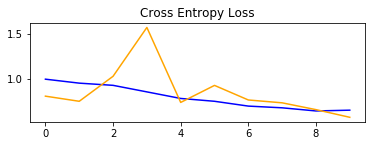

In [30]:
# cross-entropy plot
cross_entropy_plot(hist2)

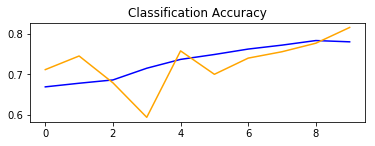

In [31]:
# accuracy plot 
classification_acc_plot(hist2)

## Predict using the New Test-Data-Set with optimized model

#### Read the Test-Images into the Test-DataSet

In [32]:
# Read the Test-Images into the TestSet 
  
path_to_test = '/content/test/*.png'
pics = glob(path_to_test)

testimages = []
tests = []
count=1
num = len(pics)

for i in pics:
    print(str(count)+'/'+str(num),end='\r')
    tests.append(i.split('/')[-1])
    testimages.append(cv2.resize(cv2.imread(i),(scale,scale)))
    count = count + 1

testimages = np.asarray(testimages)

#### Predict the Labels on the TestImage Data-Set

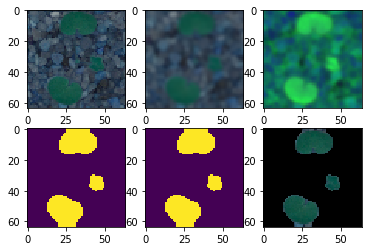

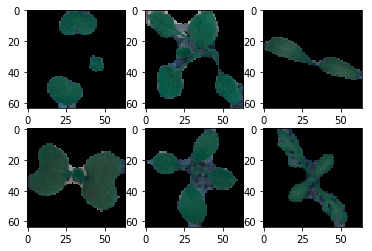

In [33]:
# Predict on the TestSet using the model 

# Before passing the TestImages to the model-prediction, preprocess as done for trainset 
newtestimages = []
sets = []
getEx = True
for i in testimages:
    blurr = cv2.GaussianBlur(i,(5,5),0)
    hsv = cv2.cvtColor(blurr,cv2.COLOR_BGR2HSV)
    
    lower = (25,40,50)
    upper = (75,255,255)
    mask = cv2.inRange(hsv,lower,upper)
    struc = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(11,11))
    mask = cv2.morphologyEx(mask,cv2.MORPH_CLOSE,struc)
    boolean = mask>0
    masking = np.zeros_like(i,np.uint8)
    masking[boolean] = i[boolean]
    newtestimages.append(masking)
    
    if getEx:
        plt.subplot(2,3,1);plt.imshow(i)
        plt.subplot(2,3,2);plt.imshow(blurr)
        plt.subplot(2,3,3);plt.imshow(hsv)
        plt.subplot(2,3,4);plt.imshow(mask)
        plt.subplot(2,3,5);plt.imshow(boolean)
        plt.subplot(2,3,6);plt.imshow(masking)
        plt.show()
        getEx=False

newtestimages = np.asarray(newtestimages)

# Display the processed/cleanedup images 
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(newtestimages[i])

In [34]:
# Predict using the model
newtestimages=newtestimages/255
prediction = model.predict(newtestimages)
pred = np.argmax(prediction,axis=1)

# Export the results into a csv file
predStr = labels.classes_[pred]
result = {'file':tests,'species':predStr}
result = pd.DataFrame(result)
result.to_csv("/gdrive/My Drive/GreatLearning/Lab/CNN_Proj/Prediction.csv",index=False)
result.head()

,file,species
0,48d97c645.png,Small-flowered Cranesbill
1,bd789d151.png,Common Chickweed
2,6680836dd.png,Sugar beet
3,1cfd91582.png,Charlock
4,aecfaed64.png,Common Chickweed
